## 电商用户与订单Python数据分析与报表生成

In [1]:
### 安装openpyxl
!pip install openpyxl

In [2]:
import pandas as pd
import pymysql
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from fpdf import FPDF

plt.rcParams["font.family"] = ["Microsoft Yahei"]
plt.rcParams["axes.unicode_minus"] = False

### 1.连接数据库

In [3]:
# 连接数据库
user = "root"
password = "20020322"
host = "localhost"
database = "ecommerce"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}?charset=utf8mb4")

# 测试连接
print("数据库连接成功！")

数据库连接成功！


### 2.从SQL中取数

In [4]:
df_user = pd.read_sql("SELECT * FROM user", engine)
df_behavior = pd.read_sql("SELECT * FROM clean_behavior", engine)
df_order = pd.read_sql("SELECT * FROM `order`", engine)
df_item = pd.read_sql("SELECT * FROM order_item", engine)

print("User：", df_user.shape)
print("User_behavior：", df_behavior.shape)
print("Order：", df_order.shape)
print("Order_item：", df_item.shape)

User： (5486, 11)
User_behavior： (14463, 15)
Order： (10996, 15)
Order_item： (27523, 7)


### 3. 数据清洗

In [5]:
# order.order_time&payment_time时间格式转换
df_order["order_time"] = pd.to_datetime(df_order["order_time"])
df_order["payment_time"] = pd.to_datetime(df_order["payment_time"])

# user_behavior时间格式转换
df_behavior["behavior_time"] = pd.to_datetime(df_behavior["behavior_time"])

# 去重
df_user = df_user.drop_duplicates("global_user_id")
df_order = df_order.drop_duplicates("order_id")

# 缺失值处理
df_order = df_order.dropna(subset=["order_id", "global_user_id"])

### 4. 业务分析

#### 4.1 整体订单指标

In [6]:
total_orders = df_order.order_id.nunique()
total_users = df_order.global_user_id.nunique()
total_sales = df_order.total_amount.sum()
avg_price = df_order.total_amount.mean()

print("===== 📊 业务核心指标 =====")
print(f"总订单数：{total_orders}")
print(f"下单用户数：{total_users}")
print(f"总销售额：{total_sales:.2f} 元")
print(f"平均客单价：{avg_price:.2f} 元")

===== 📊 业务核心指标 =====
总订单数：10996
下单用户数：4215
总销售额：27960764.82 元
平均客单价：2542.81 元


#### 4.2 用户画像

In [7]:
gender_cnt = df_user.gender.value_counts()
age_mean = df_user.age.mean()

print("===== 👤 用户画像分析 =====")
print("用户性别分布：")
print(gender_cnt)
print(f"\n用户平均年龄：{age_mean:.1f} 岁")

===== 👤 用户画像分析 =====
用户性别分布：
gender
f    2789
m    2697
Name: count, dtype: int64

用户平均年龄：39.1 岁


#### 4.3 用户行为漏斗（浏览-加购-下单）

In [8]:
funnel = df_behavior.behavior_type.value_counts()

print("===== 🛒 用户行为漏斗 =====")
print(funnel)

===== 🛒 用户行为漏斗 =====
behavior_type
浏览    3591
加购    2634
收藏    2154
下单    1864
支付    1641
评价    1341
分享    1238
Name: count, dtype: int64


#### 4.4 每日销售额趋势

In [9]:
df_order["date"] = df_order["order_time"].dt.date
daily_sales = df_order.groupby("date")["total_amount"].sum()
print("===== 📈 每日销售趋势 =====")
print(daily_sales.head(10))  # 显示前10天

===== 📈 每日销售趋势 =====
date
2025-01-01    52436.01
2025-01-02    25158.80
2025-01-03    49388.08
2025-01-04    45934.21
2025-01-05    54365.52
2025-01-06    56436.33
2025-01-07    56104.88
2025-01-08    47879.72
2025-01-09    42187.80
2025-01-10    33631.87
Name: total_amount, dtype: float64


### 5. 可视化分析

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft Yahei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False

#### 5.1 用户性别分布

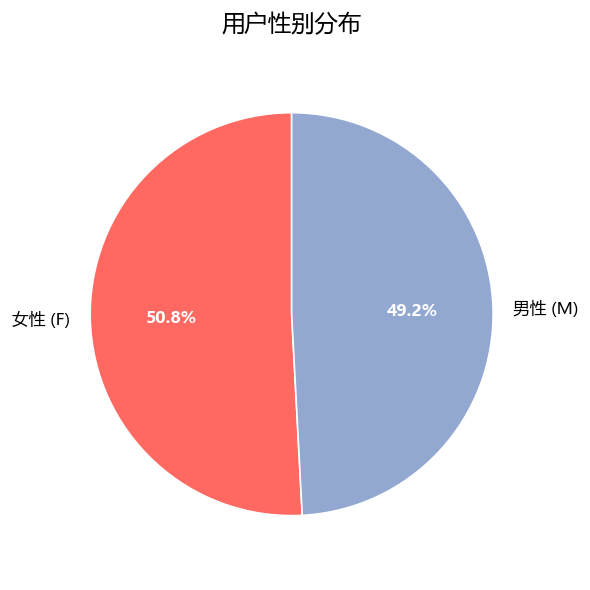

In [11]:
plt.figure(figsize=(5, 5))
colors = ['#FF6961', '#92A8D1']

wedges, texts, autotexts = plt.pie(
    gender_cnt.values,
    labels=['女性 (F)', '男性 (M)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.title('用户性别分布', fontsize=14, pad=12)
plt.axis('equal')
plt.tight_layout(pad=1)
plt.savefig("gender.png", bbox_inches='tight')
plt.show()
plt.close()

#### 5.2 用户年龄分布 + 等级分布

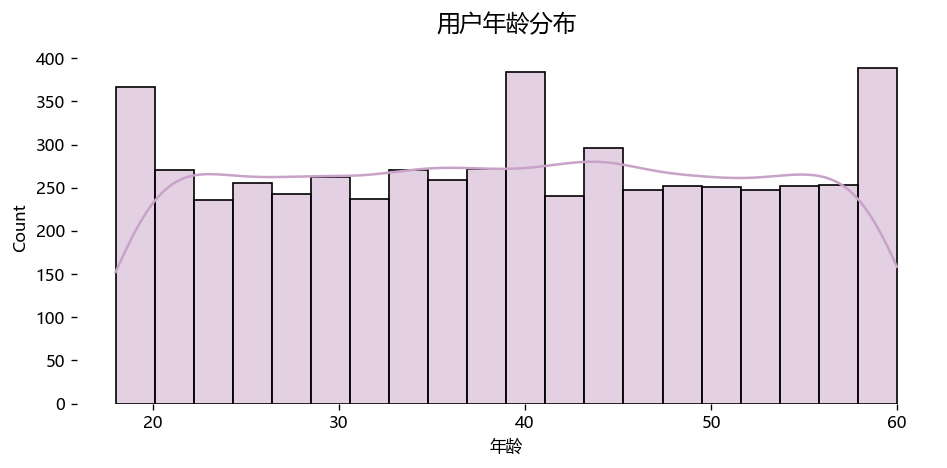

In [12]:
# 5.2.1 用户年龄分布直方图
plt.figure(figsize=(8, 4))
sns.histplot(df_user['age'], bins=20, kde=True, color="#C8A2C8")
plt.title('用户年龄分布', fontsize=14, pad=12)
plt.xlabel('年龄')
plt.tight_layout()
plt.savefig("age_dist.png", bbox_inches='tight')
plt.show()
plt.close()

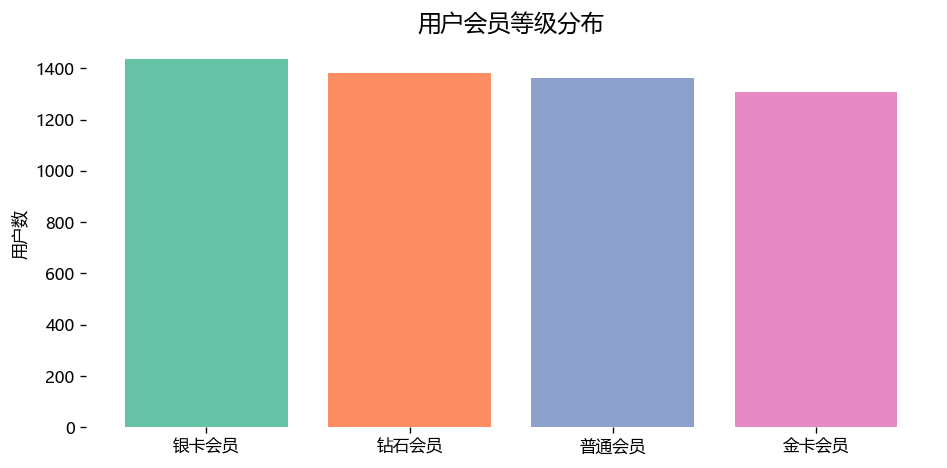

In [13]:
# 5.2.2 用户等级分布堆叠柱状图
import re

df_user['user_level_clean'] = df_user['user_level'].apply(lambda x: re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9]', '', str(x)))
level_cnt = df_user['user_level_clean'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(level_cnt.index, level_cnt.values, color=sns.color_palette("Set2", len(level_cnt)))
plt.title('用户会员等级分布', fontsize=14)
plt.ylabel('用户数')
plt.tight_layout()
plt.savefig("user_level.png", bbox_inches='tight')
plt.show()
plt.close()

#### 5.3 用户行为漏斗图

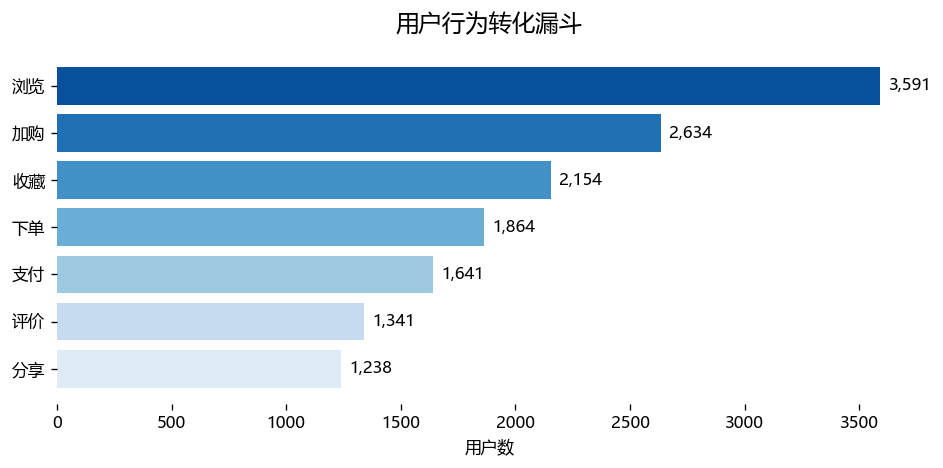

In [14]:
plt.figure(figsize=(8, 4))

funnel_sorted = funnel.sort_values(ascending=True)
colors = sns.color_palette("Blues", len(funnel_sorted))

bars = plt.barh(funnel_sorted.index, funnel_sorted.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + max(funnel_sorted)*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', va='center', fontsize=10)

plt.title('用户行为转化漏斗', fontsize=14, pad=12)
plt.xlabel('用户数')
plt.tight_layout()
plt.savefig("behavior_funnel.png", bbox_inches='tight')
plt.show()
plt.close()

#### 5.4 每日销售额趋势

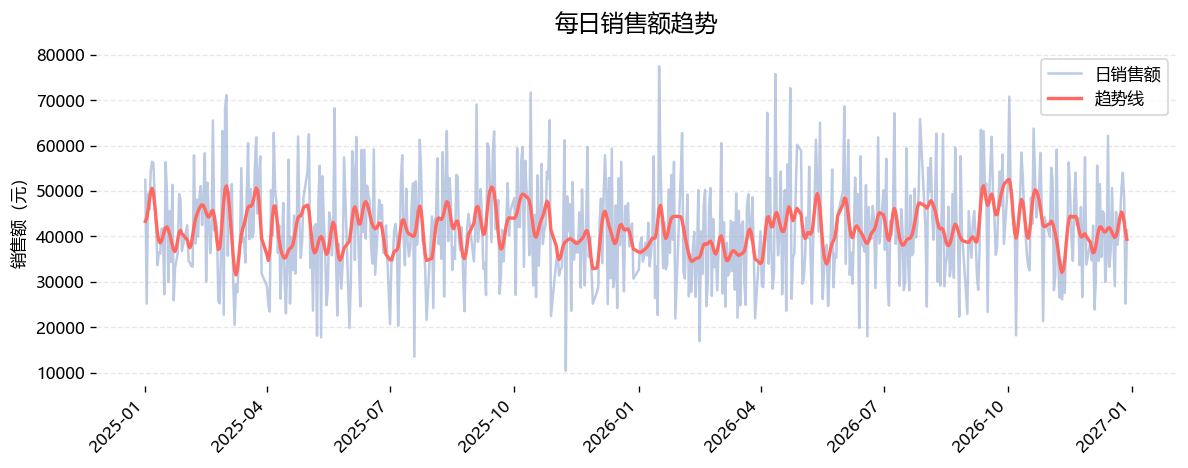

In [15]:
plt.figure(figsize=(10, 4))

plt.plot(daily_sales.index, daily_sales.values, color="#92A8D1", alpha=0.6, label='日销售额')

from scipy.ndimage import gaussian_filter1d
smooth = gaussian_filter1d(daily_sales.values, sigma=2)
plt.plot(daily_sales.index, smooth, color="#FF6961", linewidth=2, label='趋势线')

plt.title('每日销售额趋势', fontsize=14, pad=12)
plt.ylabel('销售额（元）')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("daily_sales.png", bbox_inches='tight')
plt.show()
plt.close()

#### 5.5 订单金额分布

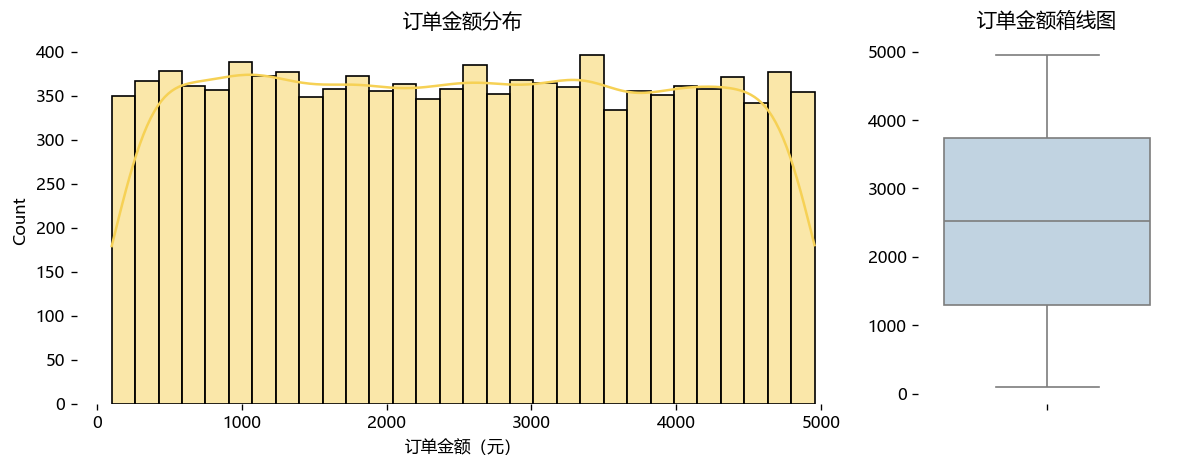

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})

filtered = df_order[df_order['total_amount'] < df_order['total_amount'].quantile(0.99)]['total_amount']
sns.histplot(filtered, bins=30, kde=True, color="#F6D155", ax=ax1)
ax1.set_title('订单金额分布', fontsize=12)
ax1.set_xlabel('订单金额（元）')

sns.boxplot(y=filtered, color="#BCD4E6", ax=ax2)
ax2.set_title('订单金额箱线图', fontsize=12)
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig("payment_dist.png", bbox_inches='tight')
plt.show()
plt.close()

### 6. Excel报表自动生成

In [17]:
from openpyxl import Workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Font, PatternFill, Alignment

wb = Workbook()
wb.remove(wb.active)

title_font = Font(name="微软雅黑", size=16, bold=True)
header_font = Font(name="微软雅黑", size=12, bold=True, color="FFFFFF")
header_fill = PatternFill("solid", fgColor="4A90E2")
center = Alignment(horizontal="center", vertical="center")

# 1. 工作表1：整体订单指标
ws1 = wb.create_sheet("整体订单指标")
ws1["A1"] = "整体订单指标"
ws1["A1"].font = title_font

ws1["A3"] = "指标名称"
ws1["B3"] = "数值"
ws1["A3"].font = header_font
ws1["B3"].font = header_font
ws1["A3"].fill = header_fill
ws1["B3"].fill = header_fill

metrics = [
    ["总订单数", total_orders],
    ["总销售额", round(total_sales, 2)],
    ["下单用户数", total_users],
    ["平均客单价", round(avg_price, 2)]
]

for i, (name, value) in enumerate(metrics, 4):
    ws1[f"A{i}"] = name
    ws1[f"B{i}"] = value
    ws1[f"A{i}"].alignment = center
    ws1[f"B{i}"].alignment = center

# 2. 工作表2：用户画像（数据+性别饼图+年龄分布+等级分布）
ws2 = wb.create_sheet("用户画像")
ws2["A1"] = "用户画像分析"
ws2["A1"].font = title_font

# 2.1 写入性别分布数据
ws2["A3"] = "用户性别分布"
ws2["A3"].font = header_font
ws2["A3"].fill = header_fill
ws2.append(["性别", "人数"])
ws2.append(["女性", gender_cnt.get("f", 0)])
ws2.append(["男性", gender_cnt.get("m", 0)])
ws2.append(["用户平均年龄", round(age_mean, 1)])

# 2.2 插入性别饼图
img_gender = Image("gender.png")
img_gender.width = 250
img_gender.height = 250
ws2.add_image(img_gender, "D3")

# 2.3 插入年龄分布直方图
img_age = Image("age_dist.png")
img_age.width = 350
img_age.height = 200
ws2.add_image(img_age, "D20")

# 2.4 插入会员等级柱状图
img_level = Image("user_level.png")
img_level.width = 350
img_level.height = 200
ws2.add_image(img_level, "D40")

# 3. 工作表3：用户行为漏斗
ws3 = wb.create_sheet("用户行为漏斗")
ws3["A1"] = "用户行为转化漏斗"
ws3["A1"].font = title_font

# 3.1 写入漏斗数据
ws3["A3"] = "行为类型"
ws3["B3"] = "用户数"
ws3["A3"].font = header_font
ws3["B3"].font = header_font
ws3["A3"].fill = header_fill
ws3["B3"].fill = header_fill

for i, (action, count) in enumerate(funnel.items(), 4):
    ws3[f"A{i}"] = action
    ws3[f"B{i}"] = count

# 3.2 插入漏斗图
img_funnel = Image("behavior_funnel.png")
img_funnel.width = 400
img_funnel.height = 200
ws3.add_image(img_funnel, "D3")

# 4. 工作表4：每日销售额趋势
ws4 = wb.create_sheet("每日销售额趋势")
ws4["A1"] = "每日销售额趋势"
ws4["A1"].font = title_font

# 4.1 写入前10天的销售数据
ws4["A3"] = "日期"
ws4["B3"] = "销售额"
ws4["A3"].font = header_font
ws4["B3"].font = header_font
ws4["A3"].fill = header_fill
ws4["B3"].fill = header_fill

for i, (date, amount) in enumerate(daily_sales.head(10).items(), 4):
    ws4[f"A{i}"] = str(date)
    ws4[f"B{i}"] = round(amount, 2)

# 4.2 插入趋势图
img_daily = Image("daily_sales.png")
img_daily.width = 500
img_daily.height = 200
ws4.add_image(img_daily, "D3")

# 5. 工作表5：订单金额分布
ws5 = wb.create_sheet("订单金额分布")
ws5["A1"] = "订单金额分布"
ws5["A1"].font = title_font

# 5.1 写入订单金额统计
ws5["A3"] = "指标"
ws5["B3"] = "数值"
ws5["A3"].font = header_font
ws5["B3"].font = header_fill
ws5["A3"].fill = header_fill

ws5.append(["订单金额平均值", round(df_order["total_amount"].mean(), 2)])
ws5.append(["订单金额中位数", round(df_order["total_amount"].median(), 2)])
ws5.append(["订单金额最大值", round(df_order["total_amount"].max(), 2)])
ws5.append(["订单金额最小值", round(df_order["total_amount"].min(), 2)])

# 5.2 插入分布图
img_payment = Image("payment_dist.png")
img_payment.width = 500
img_payment.height = 200
ws5.add_image(img_payment, "D3")

# 保存最终文件
wb.save("电商用户与订单分析报表.xlsx")
print("✅ Excel报表已生成！")

✅ Excel报表已生成！
